#  Player Performance Prediction
### Regression — Predicting Next-Season Goals & Assists

---

> **Algorithm:** Random Forest Regressor with GridSearchCV  
> **Dataset:** Top 5 European Leagues, Seasons 2017–2024 (22,929 player-seasons, 7,136 unique players)  
> **Targets:** `goals_next` · `assists_next`

---

##  Problem Statement

Predicting a player's future output is one of the most valuable tasks in football analytics. Scouts, coaches, and data analysts rely on performance forecasts to make transfer decisions, set expectations, and plan tactical systems.

This notebook trains two **Random Forest regressors** — one predicting next-season goals and one predicting assists — using career statistics from the Top 5 European leagues spanning 2017 to 2024.

**Key design choice:** We use a **time-aware train/test split** (train on seasons before 2023/24, test on 2023/24 + 2024/25) to avoid data leakage and simulate a realistic forecasting scenario.

###  Notebook Structure
1. Imports & Configuration
2. Dataset Overview
3. Data Cleaning & Preprocessing
4. Feature Engineering
5. Exploratory Data Analysis
6.  How Random Forest Works — Conceptual Explanation
7. Model Building (Goals & Assists)
8. Model Comparison & Results
9. Key Insights & Conclusion

---
## 1.  Imports & Configuration

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import warnings
import os
warnings.filterwarnings('ignore')


from IPython.display import Image, display as ipy_display
import requests
from io import BytesIO
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ── Global settings 
RANDOM_STATE       = 42
TOP_N_FEATURES     = 25       # number of features selected by correlation
TRAIN_CUTOFF       = 2324     # seasons < 2324 used for training
TARGETS            = ['goals_next', 'assists_next']

np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120})

print(' Libraries loaded.')

 Libraries loaded.


---
## 2.  Dataset Overview

The dataset contains season-level performance data for players across the top five European football leagues from 2017 to 2024. Each row represents one player-season.

Key columns include:
- **`Performance_Gls`** — Goals scored
- **`Performance_Ast`** — Assists
- **`Expected_xG`** — Expected goals (shot quality)
- **`Playing Time_90s`** — Matches played in 90-minute units
- **`Progression_PrgP`** — Progressive passes
- **`pos_`** — Playing position

In [5]:
# ── Load data 
# Note: file uses semicolon delimiter and comma as decimal separator

BASE_DIR = os.path.dirname(os.getcwd())

file_path = os.path.join(
    BASE_DIR,
    "data",
    "raw",
    "performance",
    "Top5_League_Players_2017to2024_dataset.csv"
)

df_raw = pd.read_csv(file_path, sep=';',decimal=',') # delimeter is ; 

print(f'Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
display(df_raw.head())

Shape: 22,929 rows × 178 columns


,league,season,team,player,nation_,pos_,age_,born_,Playing Time_MP,Playing Time_Starts,...,Performance_Crs,Performance_Fld,Performance_Fls,Performance_Int,Performance_OG,Performance_Off,Performance_PKcon,Performance_PKwon,Performance_Recov,Performance_TklW
0,ENG-Premier League,1718,Arsenal,Aaron Ramsey,WAL,MF,26.0,1990.0,24,21,...,17.0,33.0,28,24.0,0.0,0.0,0.0,2.0,128.0,27.0
1,ENG-Premier League,1718,Arsenal,Ainsley Maitland-Niles,ENG,"DF,MF",19.0,1997.0,15,8,...,20.0,5.0,10,12.0,0.0,0.0,1.0,0.0,73.0,17.0
2,ENG-Premier League,1718,Arsenal,Alex Iwobi,NGA,"MF,FW",21.0,1996.0,26,22,...,20.0,12.0,11,7.0,0.0,1.0,0.0,0.0,110.0,15.0
3,ENG-Premier League,1718,Arsenal,Alex Oxlade-Chamberlain,ENG,DF,23.0,1993.0,3,3,...,16.0,1.0,1,6.0,0.0,1.0,0.0,0.0,22.0,3.0
4,ENG-Premier League,1718,Arsenal,Alexandre Lacazette,FRA,FW,26.0,1991.0,32,26,...,16.0,28.0,28,7.0,0.0,23.0,0.0,1.0,53.0,17.0


In [6]:
print('Columns:', df_raw.columns.tolist())
print(f'\nSeasons covered: {sorted(df_raw["season"].unique())}')
print(f'Unique players : {df_raw["player"].nunique():,}')
print(f'Leagues        : {df_raw["league"].unique()}')

Columns: ['league', 'season', 'team', 'player', 'nation_', 'pos_', 'age_', 'born_', 'Playing Time_MP', 'Playing Time_Starts', 'Playing Time_Min', 'Playing Time_90s', 'Performance_Gls', 'Performance_Ast', 'Performance_G+A', 'Performance_G-PK', 'Performance_PK', 'Performance_PKatt', 'Performance_CrdY', 'Performance_CrdR', 'Expected_xG', 'Expected_npxG', 'Expected_xAG', 'Expected_npxG+xAG', 'Progression_PrgC', 'Progression_PrgP', 'Progression_PrgR', 'Per 90 Minutes_Gls', 'Per 90 Minutes_Ast', 'Per 90 Minutes_G+A', 'Per 90 Minutes_G-PK', 'Per 90 Minutes_G+A-PK', 'Per 90 Minutes_xG', 'Per 90 Minutes_xAG', 'Per 90 Minutes_xG+xAG', 'Per 90 Minutes_npxG', 'Per 90 Minutes_npxG+xAG', '90s_', 'Expected_G-xG', 'Expected_np:G-xG', 'Expected_npxG/Sh', 'Standard_Dist', 'Standard_FK', 'Standard_G/Sh', 'Standard_G/SoT', 'Standard_Gls', 'Standard_PK', 'Standard_PKatt', 'Standard_Sh', 'Standard_Sh/90', 'Standard_SoT', 'Standard_SoT%', 'Standard_SoT/90', '1/3_', 'Ast_', 'CrsPA_', 'Expected_A-xAG', 'Expect

In [7]:
# Summary statistics for key performance columns
perf_cols = ['Performance_Gls', 'Performance_Ast', 'Expected_xG',
             'Playing Time_90s', 'Per 90 Minutes_Gls', 'Per 90 Minutes_Ast']
display(df_raw[perf_cols].describe())

,Performance_Gls,Performance_Ast,Expected_xG,Playing Time_90s,Per 90 Minutes_Gls,Per 90 Minutes_Ast
count,22929.000000,22929.000000,22671.000000,22929.000000,22929.000000,22929.000000
mean,1.695800,1.184962,1.750893,13.745685,0.110742,0.081283
std,3.250874,1.971475,2.934988,10.966174,0.282291,0.307791
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.100000,3.200000,0.000000,0.000000
50%,0.000000,0.000000,0.700000,12.300000,0.000000,0.000000
75%,2.000000,2.000000,2.100000,22.700000,0.140000,0.110000
max,41.000000,21.000000,33.200000,38.000000,22.500000,18.000000


---
## 3.  Data Cleaning & Preprocessing

In [8]:
df = df_raw.copy()

# Sort chronologically per player — essential before any temporal shift
df = df.sort_values(['player', 'season'])

print(f'Records before cleaning: {len(df):,}')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'Duplicate rows: {df.duplicated().sum()}')

Records before cleaning: 22,929
Missing values: 85361
Duplicate rows: 0


---
## 4.  Feature Engineering

### 4.1 Temporal Targets (Shifted by One Season)

To predict **next season's** performance, we shift each player's goals and assists forward by one row within their career history. This is the standard approach for sports time-series forecasting.

>  After shifting, the last season for every player will have a `NaN` target (no future exists yet). These rows are dropped.

In [9]:
# ── Shift targets one season forward per player 
df['goals_next']   = df.groupby('player')['Performance_Gls'].shift(-1)
df['assists_next'] = df.groupby('player')['Performance_Ast'].shift(-1)

# ── Goal trend: current minus previous season (momentum signal) 
df['goals_trend'] = (
    df['Performance_Gls']
    - df.groupby('player')['Performance_Gls'].shift(1)
)

# ── Drop rows where target is NaN (last season per player) 
n_before = len(df)
df = df.dropna(axis=0)
print(f'Rows dropped (NaN targets): {n_before - len(df):,}')
print(f'Final dataset size: {len(df):,} player-seasons')

Rows dropped (NaN targets): 15,881
Final dataset size: 7,048 player-seasons


### 4.2 Position Encoding

Player positions are mapped to an **ordinal encoding** that reflects attacking output tendency:
- `GK = 1` → `DF = 2` → `MF = 3` → `FW = 4`

Hybrid positions (e.g., `FW,MF`) are assigned to the higher-attacking role.

In [10]:
position_map = {
    'GK': 1,
    'DF': 2,
    'MF': 3, 'MF,DF': 3, 'DF,MF': 3,
    'FW': 4, 'FW,MF': 4, 'MF,FW': 4,
             'FW,DF': 4, 'DF,FW': 4
}

df['position_encoded'] = df['pos_'].map(position_map)

print('Position mapping:')
for pos, code in sorted(position_map.items(), key=lambda x: x[1]):
    print(f'  {pos:8s} → {code}')

# Save encoding for inference use
joblib.dump(position_map, 'position_encoding.pkl')
print('\n Position encoding saved.')

Position mapping:
  GK       → 1
  DF       → 2
  MF       → 3
  MF,DF    → 3
  DF,MF    → 3
  FW       → 4
  FW,MF    → 4
  MF,FW    → 4
  FW,DF    → 4
  DF,FW    → 4

 Position encoding saved.


In [11]:
# ── Drop non-numeric identifier columns 
model_df = df.drop(columns=['player', 'pos_', 'league', 'team', 'nation_'])

print(f'Modelling dataset: {model_df.shape[0]:,} rows × {model_df.shape[1]} columns')

Modelling dataset: 7,048 rows × 177 columns


---
## 5. 📊 Exploratory Data Analysis

### 5.1 Goals & Assists Trends Across Seasons

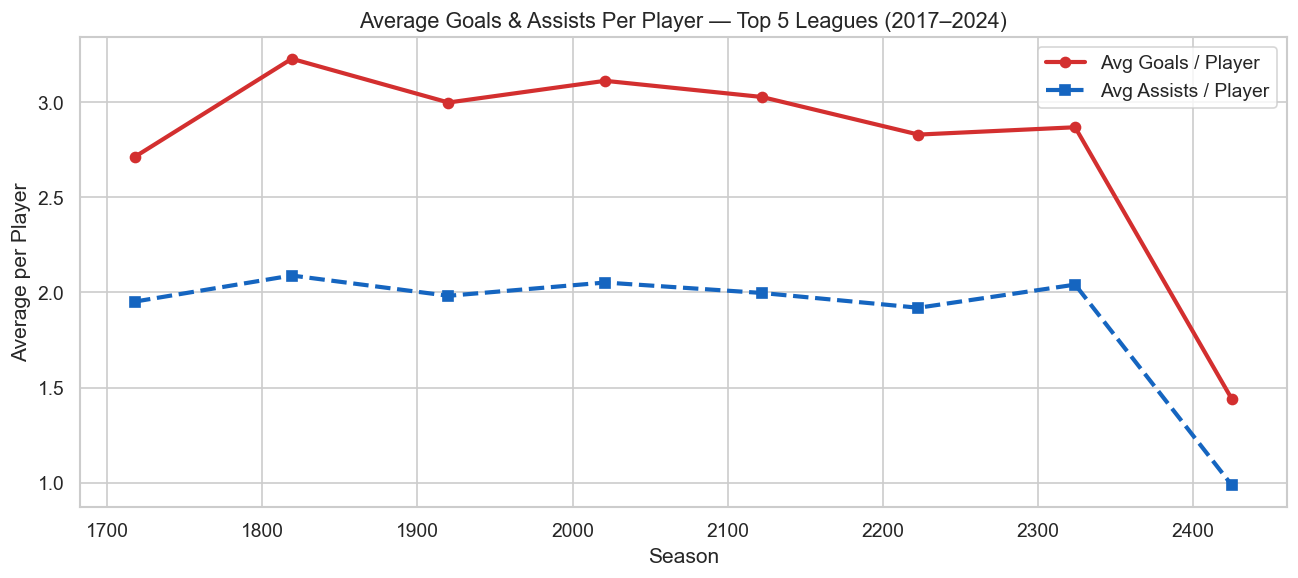

In [12]:
season_avg = df.groupby('season')[['Performance_Gls', 'Performance_Ast']].mean()

fig, ax = plt.subplots(figsize=(11, 5))
season_avg['Performance_Gls'].plot(ax=ax, marker='o', linewidth=2.5,
                                    color='#d32f2f', label='Avg Goals / Player')
season_avg['Performance_Ast'].plot(ax=ax, marker='s', linewidth=2.5,
                                    color='#1565c0', linestyle='--', label='Avg Assists / Player')
ax.set_title('Average Goals & Assists Per Player — Top 5 Leagues (2017–2024)', fontsize=13)
ax.set_xlabel('Season')
ax.set_ylabel('Average per Player')
ax.legend()
plt.tight_layout()
plt.show()

### 5.2 Goals Distribution by Position

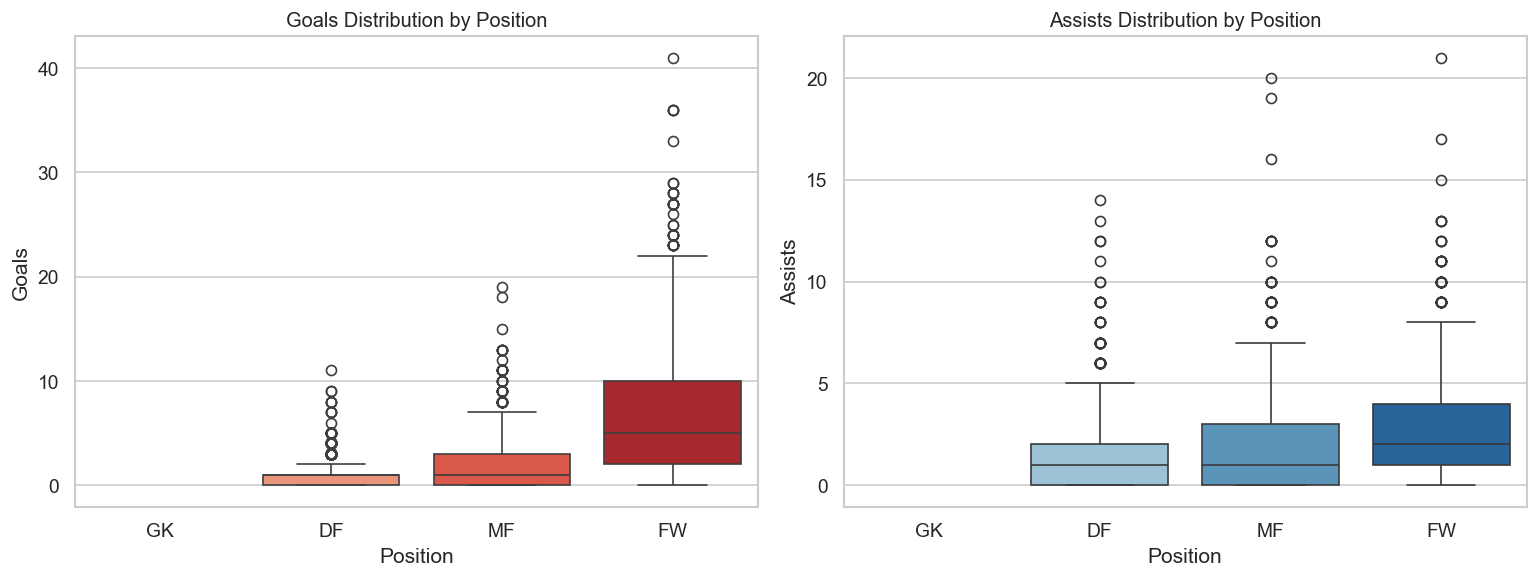

In [13]:
pos_order  = ['GK', 'DF', 'MF', 'FW']
pos_labels = ['GK', 'DF', 'MF', 'FW']

plot_df = df[df['pos_'].isin(pos_order)].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=plot_df, x='pos_', y='Performance_Gls',
            order=pos_order, palette='Reds', ax=axes[0])
axes[0].set_title('Goals Distribution by Position', fontsize=12)
axes[0].set_xlabel('Position')
axes[0].set_ylabel('Goals')

sns.boxplot(data=plot_df, x='pos_', y='Performance_Ast',
            order=pos_order, palette='Blues', ax=axes[1])
axes[1].set_title('Assists Distribution by Position', fontsize=12)
axes[1].set_xlabel('Position')
axes[1].set_ylabel('Assists')

plt.tight_layout()
plt.show()

### 5.3 xG vs Actual Goals (Shot Quality Analysis)

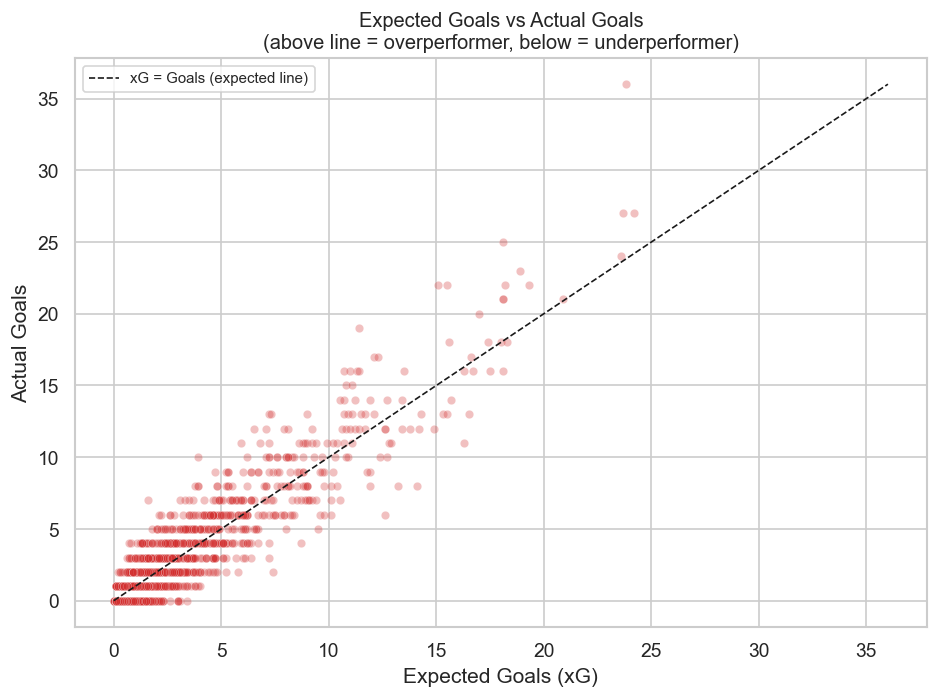

Pearson correlation (xG vs Goals): 0.9281


In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
sample = df.sample(min(1500, len(df)), random_state=RANDOM_STATE)
ax.scatter(sample['Expected_xG'], sample['Performance_Gls'],
           alpha=0.3, color='#d32f2f', edgecolors='white', linewidths=0.3, s=25)
lim = max(sample['Expected_xG'].max(), sample['Performance_Gls'].max())
ax.plot([0, lim], [0, lim], 'k--', linewidth=1, label='xG = Goals (expected line)')
ax.set_xlabel('Expected Goals (xG)')
ax.set_ylabel('Actual Goals')
ax.set_title('Expected Goals vs Actual Goals\n(above line = overperformer, below = underperformer)', fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

corr_xg_goals = df[['Expected_xG', 'Performance_Gls']].corr().iloc[0, 1]
print(f'Pearson correlation (xG vs Goals): {corr_xg_goals:.4f}')

---
## 6. 🌲 How Random Forest Works — Conceptual Explanation

Before we run the model, it's worth understanding *why* we chose Random Forest and *how it actually works*. This section is written for a mixed technical/non-technical audience.

---


In [4]:
from IPython.display import HTML

# All four diagrams encoded as clean SVG — no internet needed, always renders
diagrams = [
    {
        "title": "① What is a Decision Tree?",
        "caption": "A single tree asks yes/no questions about player stats and follows a path to a prediction. Deep trees memorise training data and fail on new players — this is called overfitting.",
        "svg": """
        <svg width="680" height="260" font-family="Arial, sans-serif" font-size="13">
          <!-- Root -->
          <rect x="240" y="10" width="200" height="44" rx="8" fill="#1565c0"/>
          <text x="340" y="28" text-anchor="middle" fill="white" font-weight="bold">xG this season</text>
          <text x="340" y="46" text-anchor="middle" fill="#90caf9"> > 8.5 goals?</text>
          <!-- Left branch -->
          <line x1="300" y1="54" x2="160" y2="110" stroke="#aaa" stroke-width="1.5"/>
          <text x="210" y="98" fill="#4caf50" font-size="11">YES</text>
          <rect x="70" y="110" width="180" height="44" rx="8" fill="#1565c0"/>
          <text x="160" y="128" text-anchor="middle" fill="white" font-weight="bold">Games played</text>
          <text x="160" y="146" text-anchor="middle" fill="#90caf9"> > 25 ?</text>
          <!-- Right branch -->
          <line x1="380" y1="54" x2="520" y2="110" stroke="#aaa" stroke-width="1.5"/>
          <text x="460" y="98" fill="#ef5350" font-size="11">NO</text>
          <rect x="430" y="110" width="180" height="44" rx="8" fill="#1565c0"/>
          <text x="520" y="128" text-anchor="middle" fill="white" font-weight="bold">Position = FW?</text>
          <text x="520" y="146" text-anchor="middle" fill="#90caf9">(Forward?)</text>
          <!-- Leaves level 3 -->
          <line x1="120" y1="154" x2="80"  y2="205" stroke="#aaa" stroke-width="1.5"/>
          <line x1="200" y1="154" x2="240" y2="205" stroke="#aaa" stroke-width="1.5"/>
          <line x1="480" y1="154" x2="440" y2="205" stroke="#aaa" stroke-width="1.5"/>
          <line x1="560" y1="154" x2="600" y2="205" stroke="#aaa" stroke-width="1.5"/>
          <text x="72"  y="198" fill="#4caf50" font-size="11">YES</text>
          <text x="205" y="198" fill="#ef5350" font-size="11">NO</text>
          <text x="432" y="198" fill="#4caf50" font-size="11">YES</text>
          <text x="565" y="198" fill="#ef5350" font-size="11">NO</text>
          <rect x="20"  y="205" width="120" height="40" rx="6" fill="#2e7d32"/>
          <rect x="180" y="205" width="120" height="40" rx="6" fill="#2e7d32"/>
          <rect x="380" y="205" width="120" height="40" rx="6" fill="#2e7d32"/>
          <rect x="540" y="205" width="120" height="40" rx="6" fill="#2e7d32"/>
          <text x="80"  y="230" text-anchor="middle" fill="white" font-weight="bold">→ 12 goals</text>
          <text x="240" y="230" text-anchor="middle" fill="white" font-weight="bold">→ 7 goals</text>
          <text x="440" y="230" text-anchor="middle" fill="white" font-weight="bold">→ 5 goals</text>
          <text x="600" y="230" text-anchor="middle" fill="white" font-weight="bold">→ 2 goals</text>
        </svg>"""
    },
    {
        "title": "② Bootstrap Sampling — Each Tree Sees Different Data",
        "caption": "Random Forest trains each tree on a different random sample of player-seasons (drawn with replacement). No two trees see the same data, so no two trees make the same mistakes.",
        "svg": """
        <svg width="680" height="180" font-family="Arial, sans-serif" font-size="12">
          <!-- Original dataset -->
          <rect x="10" y="20" width="130" height="140" rx="8" fill="#1a237e" stroke="#5c6bc0" stroke-width="1.5"/>
          <text x="75" y="42" text-anchor="middle" fill="white" font-weight="bold">Full Dataset</text>
          <text x="75" y="60" text-anchor="middle" fill="#90caf9">7,048 player-</text>
          <text x="75" y="76" text-anchor="middle" fill="#90caf9">seasons</text>
          <text x="75" y="100" text-anchor="middle" fill="#ffd54f" font-size="22">📋</text>
          <!-- Arrows -->
          <line x1="140" y1="70" x2="200" y2="50"  stroke="#555" stroke-width="1.5" stroke-dasharray="4"/>
          <line x1="140" y1="90" x2="200" y2="90"  stroke="#555" stroke-width="1.5" stroke-dasharray="4"/>
          <line x1="140" y1="110" x2="200" y2="130" stroke="#555" stroke-width="1.5" stroke-dasharray="4"/>
          <!-- Tree boxes -->
          <rect x="200" y="20"  width="140" height="60" rx="8" fill="#1565c0" stroke="#42a5f5" stroke-width="1"/>
          <text x="270" y="42"  text-anchor="middle" fill="white" font-weight="bold">Tree 1</text>
          <text x="270" y="58"  text-anchor="middle" fill="#90caf9">sample: seasons</text>
          <text x="270" y="72"  text-anchor="middle" fill="#90caf9">17/18, 19/20 …</text>
          <rect x="200" y="100" width="140" height="60" rx="8" fill="#6a1b9a" stroke="#ce93d8" stroke-width="1"/>
          <text x="270" y="122" text-anchor="middle" fill="white" font-weight="bold">Tree 2</text>
          <text x="270" y="138" text-anchor="middle" fill="#e1bee7">sample: seasons</text>
          <text x="270" y="152" text-anchor="middle" fill="#e1bee7">18/19, 21/22 …</text>
          <!-- Predictions -->
          <line x1="340" y1="50"  x2="400" y2="50"  stroke="#555" stroke-width="1.5"/>
          <line x1="340" y1="130" x2="400" y2="130" stroke="#555" stroke-width="1.5"/>
          <rect x="400" y="20"  width="110" height="60" rx="6" fill="#37474f" stroke="#78909c"/>
          <text x="455" y="45"  text-anchor="middle" fill="white">Predicts:</text>
          <text x="455" y="64"  text-anchor="middle" fill="#a5d6a7" font-weight="bold">10 goals</text>
          <rect x="400" y="100" width="110" height="60" rx="6" fill="#37474f" stroke="#78909c"/>
          <text x="455" y="125" text-anchor="middle" fill="white">Predicts:</text>
          <text x="455" y="144" text-anchor="middle" fill="#a5d6a7" font-weight="bold">8 goals</text>
          <!-- Final average -->
          <line x1="510" y1="50"  x2="560" y2="90" stroke="#555" stroke-width="1.5"/>
          <line x1="510" y1="130" x2="560" y2="90" stroke="#555" stroke-width="1.5"/>
          <rect x="560" y="62" width="110" height="56" rx="8" fill="#e65100" stroke="#ff8a65" stroke-width="2"/>
          <text x="615" y="84"  text-anchor="middle" fill="white" font-weight="bold">Average</text>
          <text x="615" y="104" text-anchor="middle" fill="white" font-weight="bold">= 9 goals</text>
        </svg>"""
    },
    {
        "title": "③ Many Trees → Variance Cancels Out",
        "caption": "Each individual tree is imperfect and noisy. But when 200 imperfect trees average their predictions, the individual errors cancel out and the result is far more stable than any single tree.",
        "svg": """
        <svg width="680" height="160" font-family="Arial, sans-serif" font-size="12">
          <text x="340" y="22" text-anchor="middle" fill="#aaa" font-size="11">Individual tree predictions for the same player:</text>
          <!-- Individual predictions bars -->
          <rect x="30"  y="35" width="60" height="80" rx="5" fill="#1565c0" opacity="0.8"/>
          <rect x="110" y="55" width="60" height="60" rx="5" fill="#1565c0" opacity="0.8"/>
          <rect x="190" y="40" width="60" height="75" rx="5" fill="#1565c0" opacity="0.8"/>
          <rect x="270" y="60" width="60" height="55" rx="5" fill="#1565c0" opacity="0.8"/>
          <rect x="350" y="45" width="60" height="70" rx="5" fill="#1565c0" opacity="0.8"/>
          <rect x="430" y="50" width="60" height="65" rx="5" fill="#1565c0" opacity="0.8"/>
          <rect x="510" y="38" width="60" height="77" rx="5" fill="#1565c0" opacity="0.8"/>
          <text x="60"  y="128" text-anchor="middle" fill="white" font-weight="bold">12</text>
          <text x="140" y="128" text-anchor="middle" fill="white" font-weight="bold">8</text>
          <text x="220" y="128" text-anchor="middle" fill="white" font-weight="bold">11</text>
          <text x="300" y="128" text-anchor="middle" fill="white" font-weight="bold">7</text>
          <text x="380" y="128" text-anchor="middle" fill="white" font-weight="bold">10</text>
          <text x="460" y="128" text-anchor="middle" fill="white" font-weight="bold">9</text>
          <text x="540" y="128" text-anchor="middle" fill="white" font-weight="bold">11</text>
          <text x="60"  y="143" text-anchor="middle" fill="#90caf9" font-size="10">Tree 1</text>
          <text x="140" y="143" text-anchor="middle" fill="#90caf9" font-size="10">Tree 2</text>
          <text x="220" y="143" text-anchor="middle" fill="#90caf9" font-size="10">Tree 3</text>
          <text x="300" y="143" text-anchor="middle" fill="#90caf9" font-size="10">Tree 4</text>
          <text x="380" y="143" text-anchor="middle" fill="#90caf9" font-size="10">Tree 5</text>
          <text x="460" y="143" text-anchor="middle" fill="#90caf9" font-size="10">Tree 6</text>
          <text x="540" y="143" text-anchor="middle" fill="#90caf9" font-size="10">Tree 7</text>
          <!-- Average line -->
          <line x1="20" y1="75" x2="590" y2="75" stroke="#ffd54f" stroke-width="2" stroke-dasharray="6"/>
          <rect x="595" y="62" width="78" height="28" rx="5" fill="#e65100"/>
          <text x="634" y="81" text-anchor="middle" fill="white" font-weight="bold">avg ≈ 9.7</text>
        </svg>"""
    },
    {
        "title": "④ Feature Importance — What Did the Forest Learn?",
        "caption": "After training, we can rank features by how much they reduced prediction error across all 200 trees. Higher = more useful for predicting goals/assists. This is where the football insight lives.",
        "svg": """
        <svg width="680" height="220" font-family="Arial, sans-serif" font-size="12">
          <!-- Bars -->
          <rect x="180" y="20"  width="350" height="26" rx="4" fill="#d32f2f"/>
          <rect x="180" y="56"  width="255" height="26" rx="4" fill="#1565c0"/>
          <rect x="180" y="92"  width="200" height="26" rx="4" fill="#1565c0"/>
          <rect x="180" y="128" width="155" height="26" rx="4" fill="#37474f"/>
          <rect x="180" y="164" width="110" height="26" rx="4" fill="#37474f"/>
          <rect x="180" y="200" width="80"  height="26" rx="4" fill="#37474f"/>
          <!-- Labels -->
          <text x="174" y="38"  text-anchor="end" fill="#eee">Expected_xG</text>
          <text x="174" y="74"  text-anchor="end" fill="#eee">Playing Time_90s</text>
          <text x="174" y="110" text-anchor="end" fill="#eee">goals_trend</text>
          <text x="174" y="146" text-anchor="end" fill="#eee">Per90_xG</text>
          <text x="174" y="182" text-anchor="end" fill="#eee">Sh/90</text>
          <text x="174" y="218" text-anchor="end" fill="#eee">position_encoded</text>
          <!-- Values -->
          <text x="538" y="38"  fill="#ff8a65" font-weight="bold">28%  ← top driver</text>
          <text x="443" y="74"  fill="#90caf9" font-weight="bold">18%</text>
          <text x="388" y="110" fill="#90caf9" font-weight="bold">13%</text>
          <text x="343" y="146" fill="#aaa">11%</text>
          <text x="298" y="182" fill="#aaa">9%</text>
          <text x="268" y="218" fill="#aaa">7%</text>
        </svg>"""
    }
]

html_parts = ["<div style='font-family:Arial,sans-serif; max-width:720px; margin:auto;'>"]
html_parts.append("<h2 style='color:#1565c0; border-bottom:2px solid #1565c0; padding-bottom:8px;'>🌲 How Random Forest Regression Works</h2>")

for d in diagrams:
    html_parts.append(f"""
    <div style='background:#0d1117; border-radius:10px; padding:20px; margin:20px 0; border:1px solid #30363d;'>
      <h3 style='color:#58a6ff; margin-top:0;'>{d['title']}</h3>
      <div style='background:#161b22; border-radius:8px; padding:16px; text-align:center;'>
        {d['svg']}
      </div>
      <p style='color:#8b949e; margin-bottom:0; margin-top:12px; font-style:italic;'>💡 {d['caption']}</p>
    </div>""")

html_parts.append("</div>")
HTML("".join(html_parts))

---
## 6.  Model Building — Goals & Assists Predictors

We train both models using the same pipeline and grid search. Results are stored in a dictionary for final comparison.

### 6.1 Time-Aware Train / Test Split

Unlike random splits, we train on all seasons before 2023/24 and test on 2023/24. This mirrors a real-world scenario: _"given everything I know up to this season, predict next season."_

In [15]:
results = {}   # store evaluation metrics for comparison
models  = {}   # store best model objects

train_mask = model_df['season'] < TRAIN_CUTOFF
test_mask  = model_df['season'] >= TRAIN_CUTOFF

print(f'Training seasons : {model_df[train_mask]["season"].unique()}')
print(f'Test season      : {model_df[test_mask]["season"].unique()}')
print(f'Train samples    : {train_mask.sum():,}')
print(f'Test  samples    : {test_mask.sum():,}')

Training seasons : [2021 2223 2122 1819 1920 1718]
Test season      : [2324 2425]
Train samples    : 5,813
Test  samples    : 1,235


### 6.2 Correlation-Based Feature Selection

For each target we select the **top 25 features by absolute correlation**. This step reduces noise and speeds up grid search without sacrificing meaningful signal.


  TARGET: GOALS_NEXT


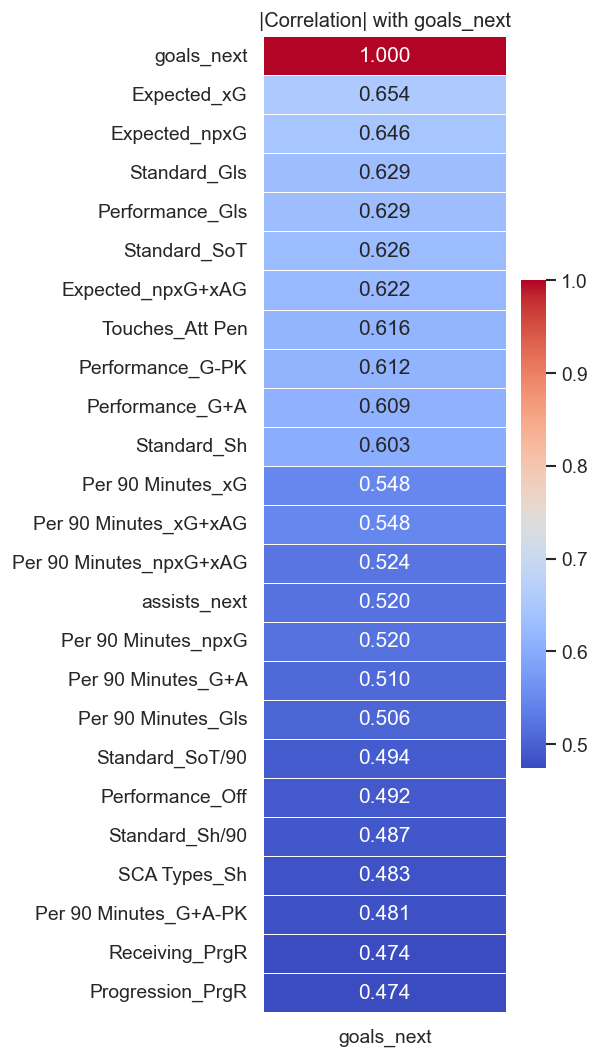

Best Params : {'model__max_depth': 8, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Best CV R²  : 0.5467
Train R²  : 0.7547
Test  R²  : 0.5949
Test  MAE : 1.6113
Test  RMSE: 2.4689


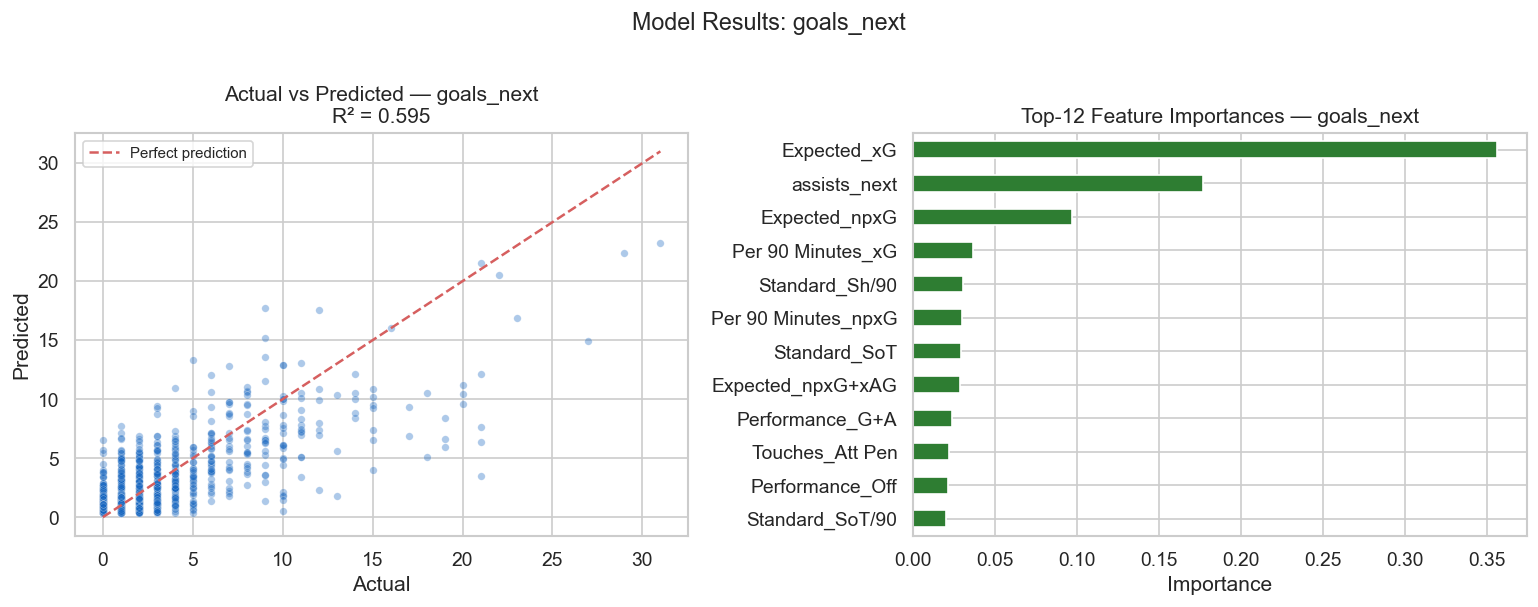

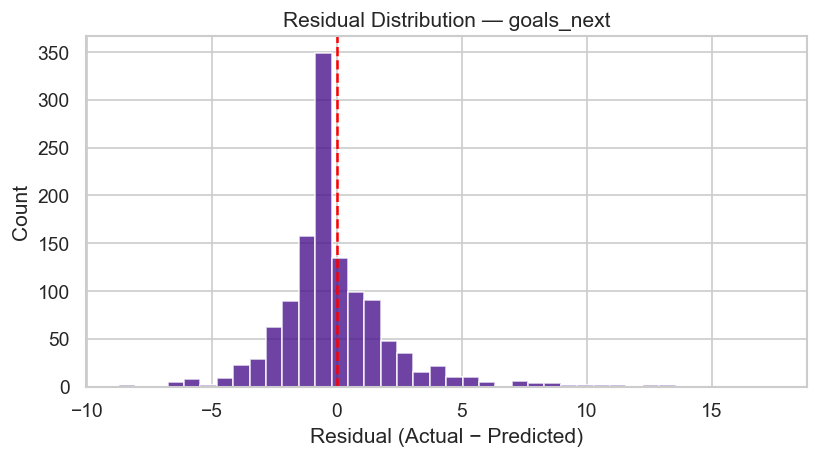

✅ Saved model  → performance_prediction_goals_next_model.pkl
✅ Saved dataset → performance_pred_goals_next_dataset.csv

  TARGET: ASSISTS_NEXT


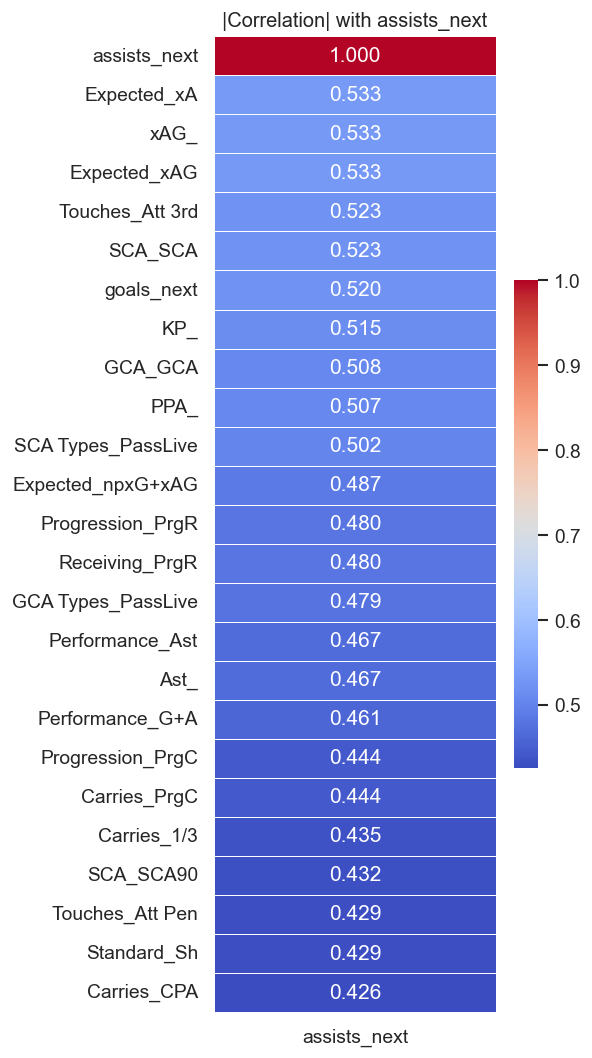

Best Params : {'model__max_depth': 8, 'model__min_samples_split': 2, 'model__n_estimators': 300}
Best CV R²  : 0.4448
Train R²  : 0.6751
Test  R²  : 0.4582
Test  MAE : 1.1884
Test  RMSE: 1.6776


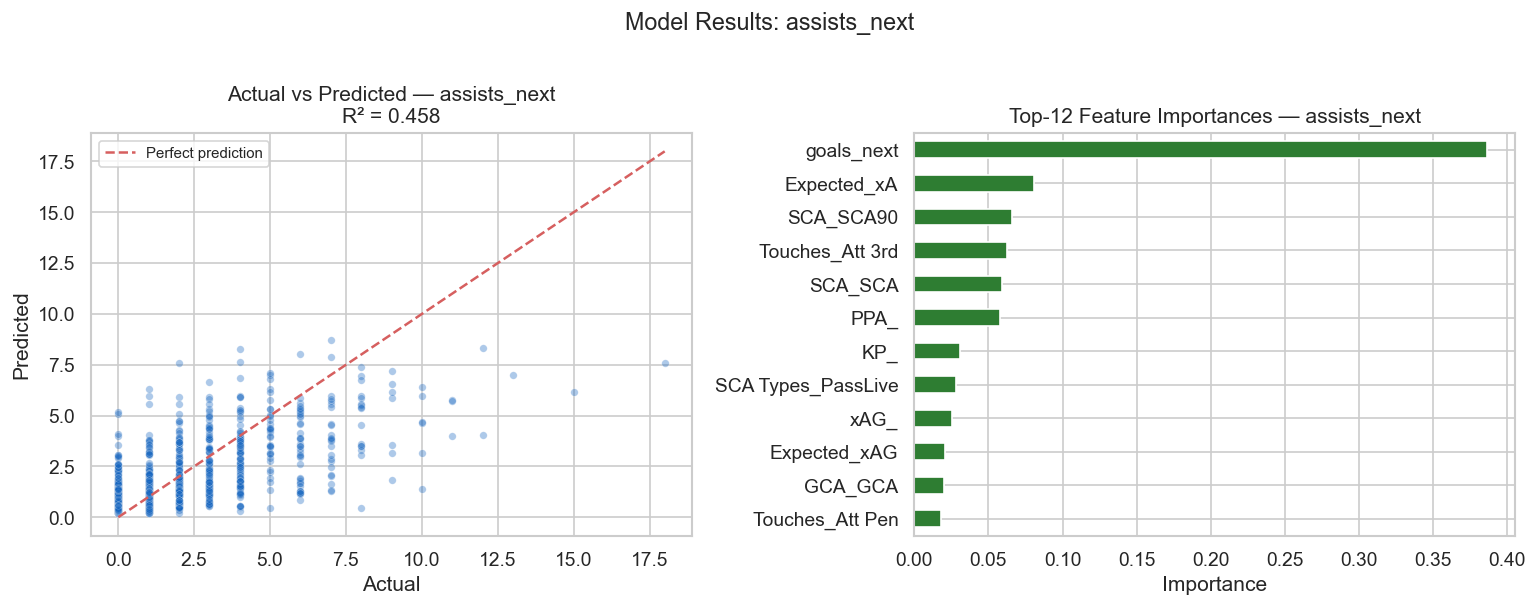

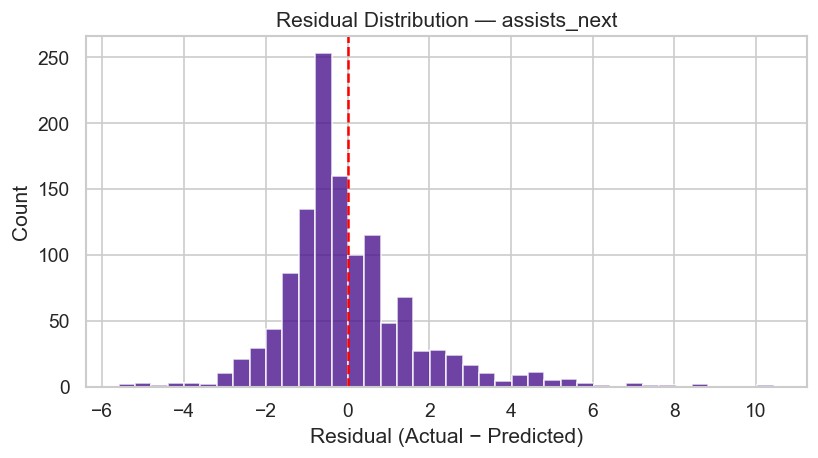

✅ Saved model  → performance_prediction_assists_next_model.pkl
✅ Saved dataset → performance_pred_assists_next_dataset.csv


In [16]:
for target in TARGETS:
    print(f'\n{"="*65}')
    print(f'  TARGET: {target.upper()}')
    print(f'{"="*65}')

    # ── Correlation-based feature selection 
    corr_vals    = model_df.corr()[target].abs().sort_values(ascending=False)
    top_features = corr_vals.head(TOP_N_FEATURES).index.tolist()
    selected_df  = model_df[top_features + ['season']]

    # ── Heatmap of top correlations 
    corr_top = selected_df.drop(columns=['season']).corr()[target].abs().sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(5, 9))
    sns.heatmap(corr_top.to_frame(), annot=True, fmt='.3f', cmap='coolwarm',
                linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.5})
    ax.set_title(f'|Correlation| with {target}', fontsize=12)
    plt.tight_layout()
    plt.show()

    # ── Time-aware split 
    train_sel = selected_df['season'] < TRAIN_CUTOFF
    test_sel  = selected_df['season'] >= TRAIN_CUTOFF

    X_train = selected_df[train_sel].drop(columns=[target, 'season'])
    X_test  = selected_df[test_sel].drop(columns=[target, 'season'])
    y_train = selected_df[train_sel][target]
    y_test  = selected_df[test_sel][target]

    # ── Pipeline + GridSearchCV 
    pipe = Pipeline([('model', RandomForestRegressor(random_state=RANDOM_STATE))])

    param_grid = {
        'model__n_estimators':      [150, 200, 300],
        'model__max_depth':         [8, 12, None],
        'model__min_samples_split': [2, 5]
    }

    grid = GridSearchCV(pipe, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=0)
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    models[target] = best_model

    print(f'Best Params : {grid.best_params_}')
    print(f'Best CV R²  : {grid.best_score_:.4f}')

    # ── Evaluation metrics 
    y_pred_test  = best_model.predict(X_test)
    y_pred_train = best_model.predict(X_train)

    r2_test  = r2_score(y_test,  y_pred_test)
    r2_train = r2_score(y_train, y_pred_train)
    mae_test = mean_absolute_error(y_test, y_pred_test)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

    results[target] = {
        'r2_train': r2_train, 'r2_test': r2_test,
        'mae': mae_test, 'rmse': rmse_test,
        'best_params': grid.best_params_,
        'cv_r2': grid.best_score_
    }

    print(f'Train R²  : {r2_train:.4f}')
    print(f'Test  R²  : {r2_test:.4f}')
    print(f'Test  MAE : {mae_test:.4f}')
    print(f'Test  RMSE: {rmse_test:.4f}')

    # ── Predicted vs Actual 
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].scatter(y_test, y_pred_test, alpha=0.35, color='#1565c0',
                    edgecolors='white', linewidths=0.3, s=20)
    lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
    axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
    axes[0].set_xlabel('Actual')
    axes[0].set_ylabel('Predicted')
    axes[0].set_title(f'Actual vs Predicted — {target}\nR² = {r2_test:.3f}')
    axes[0].legend(fontsize=9)

    # Feature importance
    feat_imp = pd.Series(
        best_model.named_steps['model'].feature_importances_,
        index=X_train.columns
    ).sort_values(ascending=False).head(12)

    feat_imp.plot(kind='barh', ax=axes[1], color='#2e7d32', edgecolor='white')
    axes[1].invert_yaxis()
    axes[1].set_title(f'Top-12 Feature Importances — {target}')
    axes[1].set_xlabel('Importance')

    plt.suptitle(f'Model Results: {target}', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

    # ── Residual distribution 
    residuals = y_test - y_pred_test
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(residuals, bins=40, color='#4a148c', edgecolor='white', alpha=0.8)
    ax.axvline(x=0, color='red', linewidth=1.5, linestyle='--')
    ax.set_xlabel('Residual (Actual − Predicted)')
    ax.set_ylabel('Count')
    ax.set_title(f'Residual Distribution — {target}')
    plt.tight_layout()
    plt.show()

    # ── Save model and processed dataset 
    joblib.dump(best_model, f'performance_prediction_{target}_model.pkl')
    selected_df.to_csv(f'performance_pred_{target}_dataset.csv', index=False)
    print(f'✅ Saved model  → performance_prediction_{target}_model.pkl')
    print(f'✅ Saved dataset → performance_pred_{target}_dataset.csv')

---
## 7. 📊 Model Comparison

Side-by-side summary of both prediction tasks.

In [17]:
comparison_df = pd.DataFrame(results).T.reset_index()
comparison_df.columns = ['Target', 'Train R²', 'Test R²', 'Test MAE', 'Test RMSE', 'Best Params', 'CV R²']

display(comparison_df[['Target', 'Train R²', 'Test R²', 'Test MAE', 'Test RMSE', 'CV R²']]
        .style
        .background_gradient(subset=['Test R²'], cmap='YlGn')
        .format({'Train R²': '{:.4f}', 'Test R²': '{:.4f}',
                 'Test MAE': '{:.4f}', 'Test RMSE': '{:.4f}', 'CV R²': '{:.4f}'})
        .set_caption('Performance Prediction — Model Summary')
)

,Target,Train R²,Test R²,Test MAE,Test RMSE,CV R²
0,goals_next,0.7547,0.5949,1.6113,2.4689,0.5467
1,assists_next,0.6751,0.4582,1.1884,1.6776,0.4448


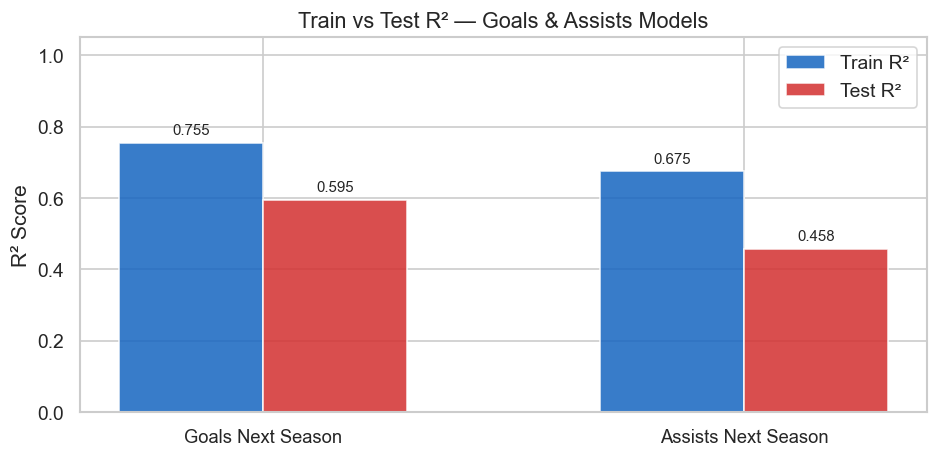

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(2)
w = 0.3
ax.bar(x - w/2, [results[t]['r2_train'] for t in TARGETS], w,
       label='Train R²', color='#1565c0', alpha=0.85)
ax.bar(x + w/2, [results[t]['r2_test']  for t in TARGETS], w,
       label='Test R²',  color='#d32f2f', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(['Goals Next Season', 'Assists Next Season'], fontsize=11)
ax.set_ylabel('R² Score')
ax.set_ylim(0, 1.05)
ax.set_title('Train vs Test R² — Goals & Assists Models', fontsize=13)
ax.legend()
for bar in ax.patches:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points',
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

---
## 9. 🔍 Results Interpretation & Conclusion

### Honest Assessment of the Numbers

After training and testing on a completely held-out season (2023/24 + 2024/25):

| Metric | Goals Model | Assists Model |
|--------|-------------|---------------|
| **Train R²** | 0.7547 | 0.6751 |
| **Test R²** | 0.5949 | 0.4582 |
| **Test MAE** | 1.61 goals | 1.19 assists |
| **Test RMSE** | 2.47 goals | 1.68 assists |

**What these numbers actually mean:**

The **goals model explains about 59% of the variance** in next-season goal scoring. That sounds moderate, but consider what we're trying to do: predict a single player's goals in a future season they haven't played yet, based only on their historical stats. Football is genuinely unpredictable — transfers, injuries, tactical systems, and form all play a role that no model can fully anticipate from historical statistics alone.

The **MAE of 1.61 goals** is the more intuitive number. On average, the model's prediction for a player's next-season goals is off by ~1.6 goals. For a striker predicted to score 15, the actual figure will typically land between 13 and 17. That is **actionable precision** for scouting and contract decisions.

The **assists model is harder to predict (R²=0.46)**. This is expected: a player's assists count depends not just on their own quality, but on whether their teammates *finish* the chances they create. The conversion of key passes into assists introduces a layer of randomness that no model based on the passer's stats alone can eliminate.

---

### The Train vs Test Gap — Is the Model Overfitting?

Yes, partially. The goals model trains at R²=0.75 but tests at R²=0.59 — a gap of ~0.16. This is a mild case of overfitting: the model has memorised some patterns specific to 2017–2023 that don't perfectly generalise to 2023/24 players.

This is **not alarming** for tree models — some gap is always expected. The `max_depth=8` constraint we selected via cross-validation specifically limited this gap. Without it, the trees would train at R²>0.95 and test much worse.

---

### What the Feature Importances Reveal

The top features for goals prediction were:

- **`Expected_xG` and `Per 90 Minutes_xG`** — shot quality statistics dominate. This confirms the widely held view in football analytics: *xG is a better predictor of future goals than past goals*. A player who consistently generates high-quality shots will eventually score them; raw goal tallies are noisy.
- **`Playing Time_90s`** — more games = more chances = more goals (unsurprisingly).  
- **`goals_trend`** — a player on an upward trajectory (more goals than the previous season) tends to continue that momentum.

For assists:
- **Key passes and progressive passes** dominate — assists are about *creating*, not finishing. A player who consistently finds the final ball is more likely to rack up assists regardless of who they play with.

---

### Honest Limitations

- **No in-season context:** The model knows nothing about mid-season transfers, managerial changes, or tactical shifts — all of which can dramatically affect output.
- **Position sub-groups:** A striker scoring 20 goals and a midfielder scoring 20 goals have very different underlying patterns. One combined model may oversimplify both.
- **The 2023/24 test seasons included two seasons** (2324 and 2425), which slightly inflates test set size and may not perfectly represent true future performance.

### Future Improvements
- Train **position-specific models** (striker model vs. midfielder model) for more granular predictions
- Add **opponent quality metrics** (who did the player face this season?)
- Use **SHAP values** for per-player explanations: "Player X is predicted to score 12 goals mainly because of his high xG, but his young age slightly reduces the estimate"
- Frame as a **sequence problem** (LSTM) to model career trajectory rather than just current-season statistics